In [186]:
# Q.N.1 Import Pandas, Matplotlib, Numpy, Statsmodels, Seaborn,and scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_white, het_breuschpagan

In [187]:
#Q.N.2 Import CSV file into Python as a Pandas dataframe and show top 5 Rows 
dataframe = pd.read_csv('cars24data.csv')
dataframe.head(5) 

,Model Name,Price,Manufacturing_year,Engine capacity,Spare key,Transmission,KM driven,Ownership,Fuel type,Imperfections,Repainted Parts
0,2017 Maruti Swift VXI,561000,2017,1197,No,Manual,25847,2,Petrol,6,2
1,2016 Maruti Baleno DELTA PETROL 1.2,498000,2016,1197,Yes,Manual,55511,2,Petrol,12,1
2,2020 Maruti Swift VXI,577000,2020,1197,No,Manual,47110,1,Petrol,4,2
3,2022 Maruti Ertiga VXI AT SHVS,1084000,2022,1462,Yes,Automatic,35378,1,Petrol,2,3
4,2019 Maruti Dzire VXI,603000,2019,1197,Yes,Manual,91856,1,Petrol,3,2


In [188]:
#Q.N.3 print the summary statistics 
dataframe.describe()

,Price,Manufacturing_year,Engine capacity,KM driven,Ownership,Imperfections,Repainted Parts
count,1.445000e+03,1445.000000,1445.000000,1445.000000,1445.000000,1445.000000,1445.000000
mean,5.263543e+05,2017.817301,1142.104498,50588.903114,1.285121,9.597232,3.228374
std,1.963696e+05,2.986554,169.020818,27339.562631,0.489877,8.398637,3.364578
min,1.390000e+05,2010.000000,796.000000,1207.000000,1.000000,0.000000,0.000000
25%,3.900000e+05,2016.000000,998.000000,28803.000000,1.000000,3.000000,0.000000
50%,5.010000e+05,2018.000000,1197.000000,47849.000000,1.000000,8.000000,2.000000
75%,6.310000e+05,2020.000000,1197.000000,70337.000000,2.000000,14.000000,5.000000
max,1.599000e+06,2023.000000,1462.000000,124716.000000,3.000000,43.000000,27.000000


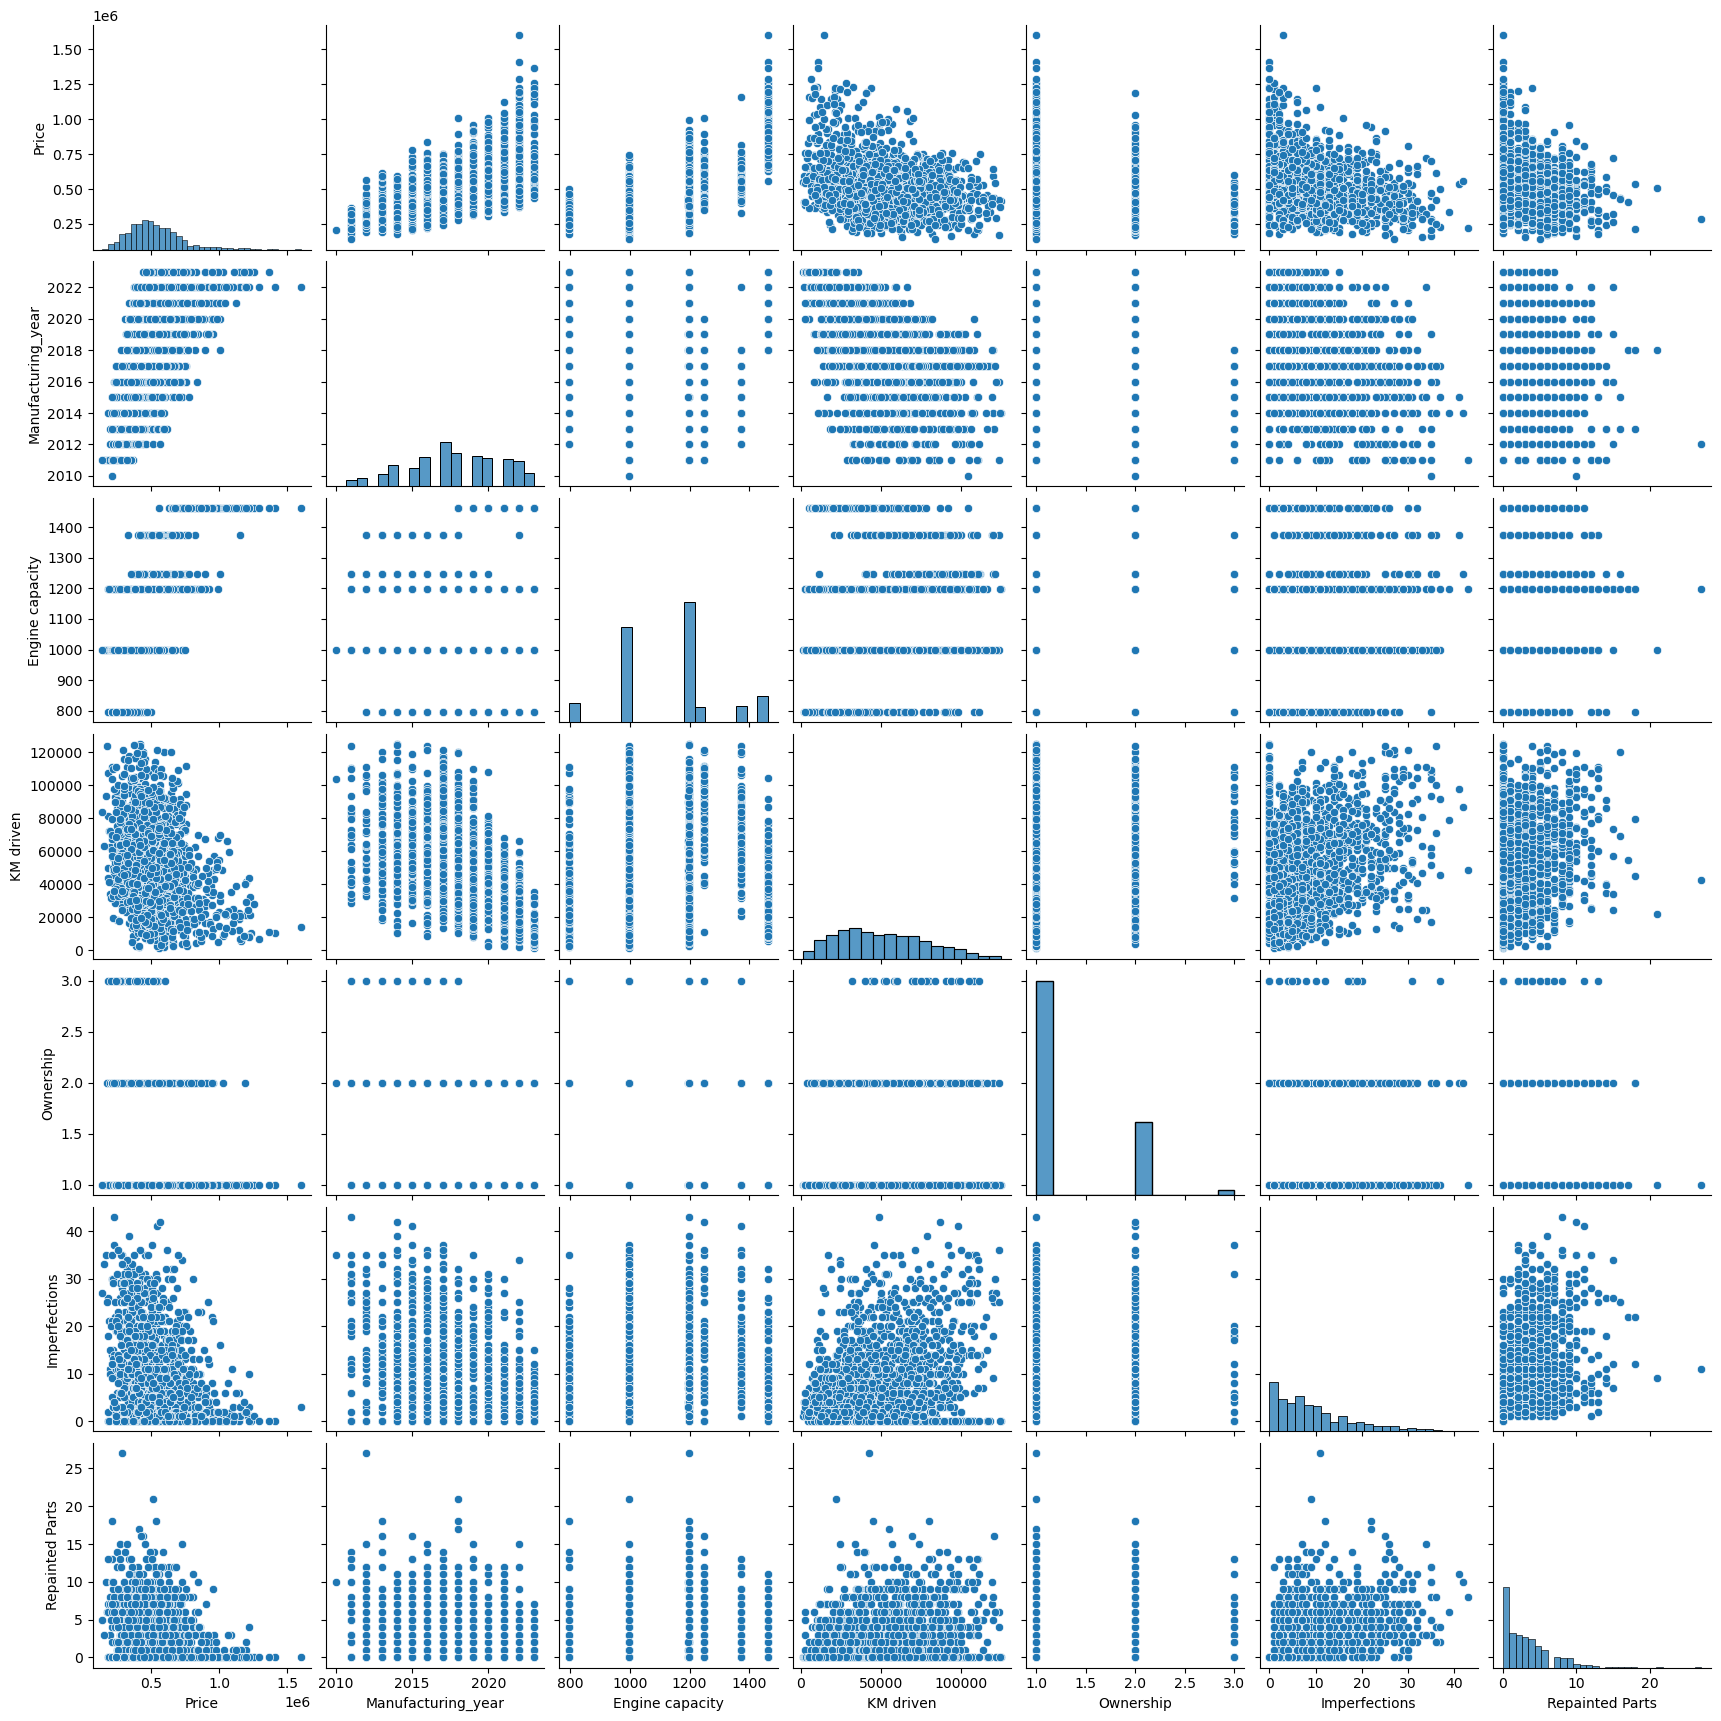

In [189]:
 # Q.N.4 Seaborn’s pairplot function to produce the graphics 
sns.pairplot(dataframe)
plt.show()

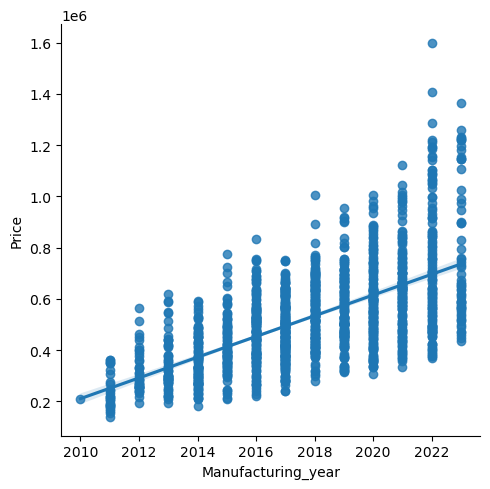

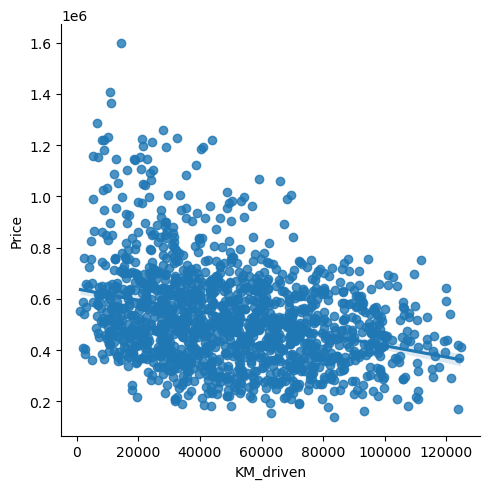

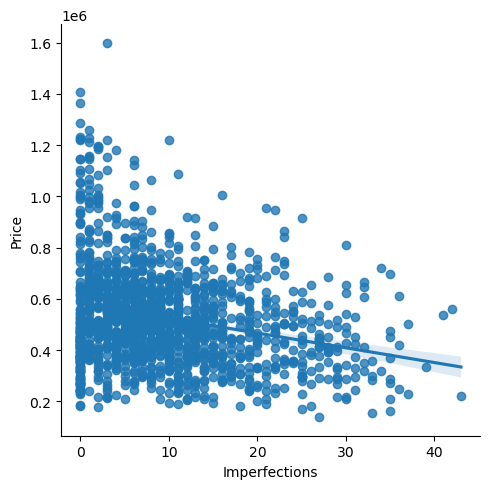

In [198]:
# Q.N.5 list of independent variables and a loop to create a plot of each one against dependent variables.  

iv  = dataframe['Price']
dv = ['Manufacturing_year','KM_driven', 'Imperfections']
for i in dv:
    X = dataframe[i]
    sns.lmplot(x=i,y='Price',data= dataframe)

    


In [199]:
# Q.N.6 Create three different linear regression models using different subsets of independent variables. Print a summary of the regression results for each model. 
model1 = sm.OLS(iv,X)
sm.OLS.from_formula('Price ~ Manufacturing_year', dataframe)
result1 = model1.fit()
result1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.421
Model:                            OLS   Adj. R-squared (uncentered):              0.420
Method:                 Least Squares   F-statistic:                              1049.
Date:                Sun, 12 Oct 2025   Prob (F-statistic):                   2.13e-173
Time:                        12:41:22   Log-Likelihood:                         -20786.
No. Observations:                1445   AIC:                                  4.157e+04
Df Residuals:                    1444   BIC:                                  4.158e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Imperfections  2.858e+04    882.415     32.383      0.000    2.68e+04    3.03e+04
==============================================================================
Omnibus:                       29.150   Durbin-Watson:                   1.185
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.663
Skew:                          -0.181   Prob(JB):                     1.21e-10
Kurtosis:                       3.792   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [193]:
dataframe = dataframe.rename(columns={'KM driven': 'KM_driven'})
model2 = sm.OLS.from_formula('Price ~ Manufacturing_year + KM_driven', dataframe)
results2 = model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     439.5
Date:                Sun, 12 Oct 2025   Prob (F-statistic):          9.13e-150
Time:                        12:19:49   Log-Likelihood:                -19317.
No. Observations:                1445   AIC:                         3.864e+04
Df Residuals:                    1442   BIC:                         3.866e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          -8.274e+07   3.25e+06    -25.445      0.000   -8.91e+07   -7.64e+07
Manufacturing_year  4.126e+04   1609.207     25.642      0.000    3.81e+04    4.44e+04
KM_driven              0.1693      0.176      0.963      0.336      -0.176       0.514
==============================================================================
Omnibus:                      192.664   Durbin-Watson:                   1.792
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              346.633
Skew:                           0.849   Prob(JB):                     5.36e-76
Kurtosis:                       4.696   Cond. No.                     4.59e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.59e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [201]:
dataframe = dataframe.rename(columns={'KM Driven': 'KM_driven'})
dataframe = dataframe.rename(columns={'KM driven': 'KM_driven'})
model3 = sm.OLS.from_formula('Price ~ Manufacturing_year + KM_driven + Ownership', dataframe)
results3 = model3.fit()
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     297.8
Date:                Sun, 12 Oct 2025   Prob (F-statistic):          2.09e-150
Time:                        12:41:33   Log-Likelihood:                -19313.
No. Observations:                1445   AIC:                         3.863e+04
Df Residuals:                    1441   BIC:                         3.865e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          -8.127e+07   3.28e+06    -24.792      0.000   -8.77e+07   -7.48e+07
Manufacturing_year  4.055e+04   1621.540     25.007      0.000    3.74e+04    4.37e+04
KM_driven              0.2137      0.176      1.215      0.225      -0.131       0.559
Ownership          -2.604e+04   8529.518     -3.053      0.002   -4.28e+04   -9309.317
==============================================================================
Omnibus:                      191.187   Durbin-Watson:                   1.789
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              342.036
Skew:                           0.846   Prob(JB):                     5.34e-75
Kurtosis:                       4.679   Cond. No.                     4.64e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.64e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [202]:
# Q.N.7 models using the four different selection statistics we discussed. (R^2, AIC…) and select one as your best model.  
model = ['model1','model2','model3']
r_seq = [result1.rsquared, results2.rsquared,results3.rsquared]
r_seq_adj = [result1.rsquared_adj, results2.rsquared_adj, results3.rsquared_adj]
aic = [result1.aic,results2.aic,results3.aic]
bic = [result1.bic, results2.bic, results3.bic]
data = {
    "Model": model,
    "R-squared" : r_seq,
    "Adjusted R-squared" : r_seq_adj,
    "AIC" : aic,
    "BIC" : bic
}
table = pd.DataFrame(data)
print(table)

    Model  R-squared  Adjusted R-squared           AIC           BIC
0  model1   0.420695            0.420294  41574.127419  41579.403284
1  model2   0.378719            0.377858  38640.560935  38656.388529
2  model3   0.382712            0.381427  38633.244138  38654.347596


In [203]:
# Q.N.8 Calculation of the variance inflation factor for independent variables to check for multicollinearity among variables. 

vif = pd.DataFrame()
dataframe = dataframe.rename(columns={'KM_driven': 'KM_driven'})
X = dataframe[dv]
vif['variable'] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Variance Inflation Factor (VIF) for Multicollinearity:")
print(vif)

print('___________________________________________________________')
vif_greater_than_1 = vif[vif['VIF'] > 1]['variable'].tolist()
vif_greater_than_5 = vif[vif['VIF'] > 5]['variable'].tolist()
vif_greater_than_10 = vif[vif['VIF'] > 10]['variable'].tolist()
print("Variables with VIF > 5:", vif_greater_than_5)
print("Variables with VIF > 10:", vif_greater_than_10)

Variance Inflation Factor (VIF) for Multicollinearity:
             variable       VIF
0  Manufacturing_year  4.865951
1           KM_driven  4.753019
2       Imperfections  2.481411
___________________________________________________________
Variables with VIF > 5: []
Variables with VIF > 10: []


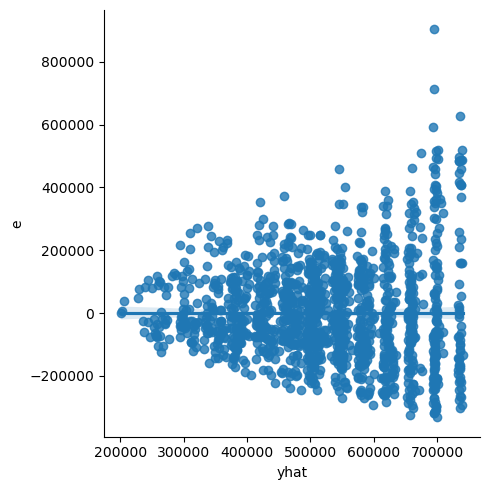

In [204]:
# Q.N.9 Using the best model(Model3), create a variable containing the predicted values of Y, called y-hat, and a variable containing the residuals called e.   
#Make a scatterplot with the residuals on the y-axis and the predicted values on the x-axis.  

#Gather Regression Statistics and Values
rsquared3 = results3.rsquared
adj_rsquared3 = results3.rsquared_adj
fstat3 = results3.fvalue
aic3 = results3.aic
bic3 = results3.bic
parameters3 = results3.params
tvalues3 = results3.tvalues
pvalues3 = results3.pvalues
ci1 = results3.conf_int(alpha=0.05)


#Generate fitted values and residuals for the model
yhat = results3.fittedvalues
e = results3.resid
#Add fitted values and residuals to original dataframe for simplicity of plotting
dataframe['yhat'] = yhat
dataframe['e'] = e
dataframe.head()

#Plot the fitted values against the residuals
sns.lmplot(x='yhat',y='e', fit_reg=True, data=dataframe)
plt.show()

-2.7029945879246536e-07


(array([ 99., 330., 494., 340., 118.,  40.,  20.,   2.,   1.,   1.]),
 array([-331961.18800594, -208429.15833529,  -84897.12866465,
          38634.901006  ,  162166.93067664,  285698.96034729,
         409230.99001793,  532763.01968858,  656295.04935922,
         779827.07902986,  903359.10870051]),
 <BarContainer object of 10 artists>)

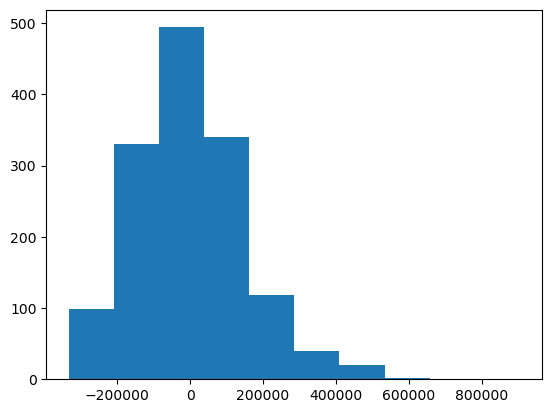

In [205]:
#Q.N.1O) Plot a histogram of the residuals to check that data is normally distributed. Tell me if data is normally distributed or not. 

print(e.mean())
plt.hist(e)

In [206]:
# Q.N. 11 Use a statistical test to test for heteroskedasticity (BP test).  Tell me if you think heteroskedasticity is present or not.

#Statistical tests for heteroskedasticity - Breusch Pagan and White
#HO: homoskedasticity, HA: heteroskedasticity
X = sm.add_constant(X)
white_test = het_white(e, X)
bp_test = het_breuschpagan(e, X)
print("White's Test P-Value")
#print("LM Statistic:", white_test[0])
print("LM P-value:", white_test[1])
#print("F-Statistic:", white_test[2])
#print("F P-value:", white_test[3])
print("Breusch Pagan Test P-Value:")
print(bp_test[3])

White's Test P-Value
LM P-value: 5.809758854711658e-43
Breusch Pagan Test P-Value:
2.2009539639660212e-37


In [207]:
# Q.N 12 Standardize your residuals to check for outliers.  Tell me which, if any, of your observations meet the rule of thumb threshold for outliers.  Remove these observations.

#Outlier Detection - Studentized residuals
#Get influence measures
influence = results3.get_influence()
#Calculate studentized residuals
studentized_residuals = influence.resid_studentized_external
#Identify outliers using the common thresholds 
mild_outliers = np.where(np.abs(studentized_residuals) > 2)[0]
extreme_outliers = np.where(np.abs(studentized_residuals) > 3)[0]

print("Mild Outliers:", mild_outliers)
print("Extreme Outliers:", extreme_outliers)
#List of Outlers to be removed [  68  243  275  347  359  368  469  494  498  564  565  594  929 1056 1061 1095 1170]

Mild Outliers: [   3   12   52   54   55   68   73   78  199  200  217  219  243  245
  251  275  276  292  347  359  368  369  371  439  463  469  494  496
  498  557  563  564  565  571  584  594  607  630  699  710  785  831
  929  932 1036 1048 1056 1059 1061 1062 1095 1136 1162 1170 1190 1198
 1209 1220 1240 1254 1280 1302 1338 1423]
Extreme Outliers: [  68  243  275  347  359  368  469  494  498  564  565  594  929 1056
 1061 1095 1170]


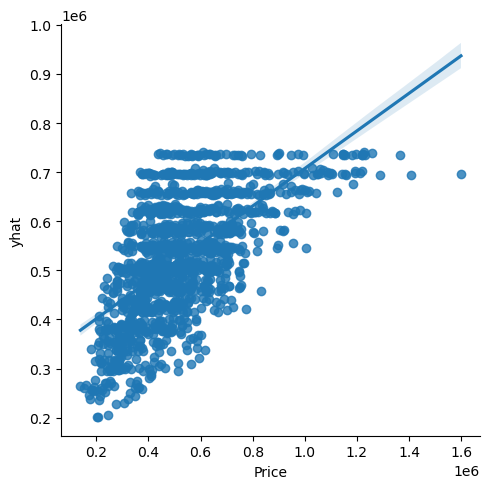

In [208]:
# Q.N 13 Create a scatterplot of Y vs Y-Hat.  Include a trendline.


sns.lmplot(x='Price',y='yhat', fit_reg=True, data=dataframe)

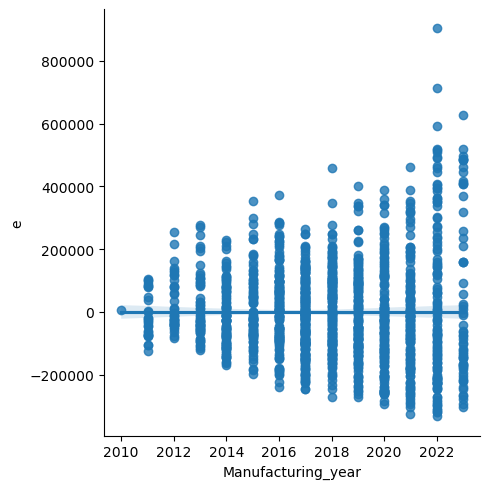

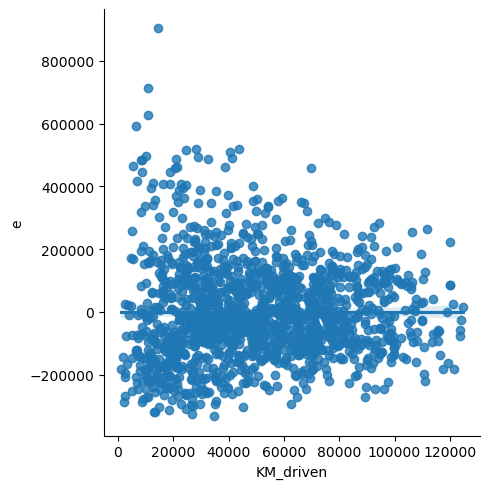

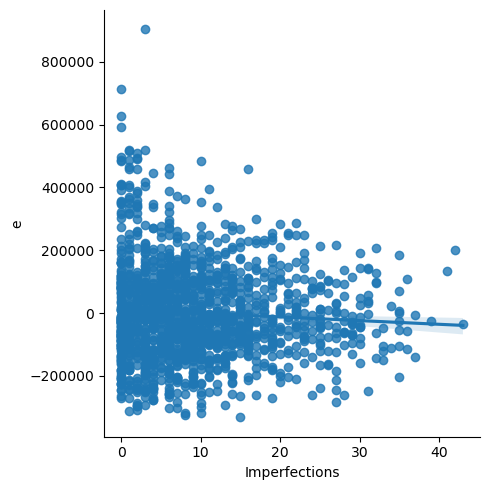

In [209]:
# Q.N14 Create a loop that loops through your x-variables and plots them against your residuals.  Display the plots.  Tell me if you see any problematic patterns.

for i in dv:
    sns.lmplot(x=i,y='e', fit_reg=True, data=dataframe)    


# Answer: Not any problematic patterns found after analyzing the patterns below.

In [211]:
#Q.N 15 Create a new dataframe with five hypothetical observations’ worth of x-values and use the predict function to calculate the estimated y values for each set of x values.
#1st prediction:
#Manufacturing_year','KM_driven', 'Imperfections
predictions1 = pd.DataFrame({'Manufacturing_year': [2017],
                            'KM_driven': [12355],
                            'Ownership':[2], 
                            })
preidictions1 = sm.add_constant(predictions1)

predictions1['Market_price'] = results3.predict(predictions1)
print(predictions1)

   Manufacturing_year  KM_driven  Ownership   Market_price
0                2017      12355          2  466426.582269


In [212]:
 
predictions2 = pd.DataFrame({'Manufacturing_year': [2020],
                            'KM_driven': [15000],
                            'Ownership':[5], 
                            })
preidictions2 = sm.add_constant(predictions2)

predictions2['Market_price'] = results3.predict(predictions2)
print(predictions2)

   Manufacturing_year  KM_driven  Ownership   Market_price
0                2020      15000          5  510516.281651


In [213]:
 
predictions2 = pd.DataFrame({'Manufacturing_year': [2023],
                            'KM_driven': [25000],
                            'Ownership':[2], 
                            })
preidictions2 = sm.add_constant(predictions2)

predictions2['Market_price'] = results3.predict(predictions2)
print(predictions2)

   Manufacturing_year  KM_driven  Ownership   Market_price
0                2023      25000          2  712423.307382


In [214]:
 
predictions3 = pd.DataFrame({'Manufacturing_year': [2010],
                            'KM_driven': [40000],
                            'Ownership':[6], 
                            })
preidictions3 = sm.add_constant(predictions3)

predictions3['Market_price'] = results3.predict(predictions3)
print(predictions3)

   Manufacturing_year  KM_driven  Ownership  Market_price
0                2010      40000          6  84327.361888


In [219]:
predictions4 = pd.DataFrame({'Manufacturing_year': [2014],
                            'KM_driven': [10000],
                            'Ownership':[1], 
                            })
preidictions4 = sm.add_constant(predictions4)

predictions4['Market_price'] = results3.predict(predictions4)
print(predictions4)

   Manufacturing_year  KM_driven  Ownership   Market_price
0                2014      10000          1  370317.020252


In [220]:
predictions5 = pd.DataFrame({'Manufacturing_year': [2016],
                            'KM_driven': [20000],
                            'Ownership':[6], 
                            })
preidictions5 = sm.add_constant(predictions5)

predictions5['Market_price'] = results3.predict(predictions5)
print(predictions5)

   Manufacturing_year  KM_driven  Ownership   Market_price
0                2016      20000          6  323347.628454


In [ ]:
#Q.N 16 Explain any shortcoming of your model, difficulties you encountered, extensions you’d add to improve the study, etc.  This should be at least 3-5 sentences.
-> One of the major weaknesses in my model is that it only explains about 40% of the car price variance, which
shows there may be some other important factors left out of the equation like reputation of the brand it's 
affiliated with, the type of car it is or the state of the car. I also found the data displayed heteroskedasticity,
which showed the residuals did not include constant variance. There also seemed to be quite a number of outliers 
that affected the model's efficacy. Another challenge was how to handle the multicollinearity and ensure the 
variables stayed scaled and in the right format. In the case the study is to be carried out further, more 
predictors would be added and potentially higher order models like Random Forest or Gradient Boosting would be
utilized in an effort to become more precise with the predictions.

In [ ]:
#Q.N 17 Tell me what you found!  Explain the study you just conducted and any interesting results.  This should be at least 3-5 sentences.
-> I used linear regression to identify what affects the price of old vehicles. I created three models and 
discovered the best one used year of manufacture, kilometers covered, and ownership/number of owners. The model 
revealed that newer cars sold higher prices and cars with more owners sold lower prices. Although the model wasn't
perfect, it did an excellent jobmirroring overall automobile price trends. This study signaled clearly the way 
simple variables can influence used automobile prices and gave a strong base for deeper research later on.